Epoch 001 | Acc=0.537 | Φ*=5.589138
Epoch 002 | Acc=0.529 | Φ*=3.856619
Epoch 003 | Acc=0.542 | Φ*=4.302507
Epoch 004 | Acc=0.550 | Φ*=6.075235
Epoch 005 | Acc=0.601 | Φ*=5.361861
Epoch 006 | Acc=0.551 | Φ*=6.160718
Epoch 007 | Acc=0.540 | Φ*=5.133308
Epoch 008 | Acc=0.585 | Φ*=6.224113
Epoch 009 | Acc=0.538 | Φ*=6.880750
Epoch 010 | Acc=0.528 | Φ*=10.197582
Epoch 011 | Acc=0.570 | Φ*=9.117871
Epoch 012 | Acc=0.518 | Φ*=10.819879
Epoch 013 | Acc=0.537 | Φ*=9.934785
Epoch 014 | Acc=0.595 | Φ*=11.646186
Epoch 015 | Acc=0.595 | Φ*=11.811683
Epoch 016 | Acc=0.529 | Φ*=9.628546
Epoch 017 | Acc=0.572 | Φ*=11.014055
Epoch 018 | Acc=0.603 | Φ*=12.171059
Epoch 019 | Acc=0.576 | Φ*=10.492268
Epoch 020 | Acc=0.599 | Φ*=13.822972
Epoch 021 | Acc=0.669 | Φ*=20.054507
Epoch 022 | Acc=0.669 | Φ*=20.391516
Epoch 023 | Acc=0.632 | Φ*=16.921930
Epoch 024 | Acc=0.663 | Φ*=20.694826
Epoch 025 | Acc=0.662 | Φ*=19.723290
Epoch 026 | Acc=0.661 | Φ*=20.837521
Epoch 027 | Acc=0.662 | Φ*=20.883288
Epoch 028 | A

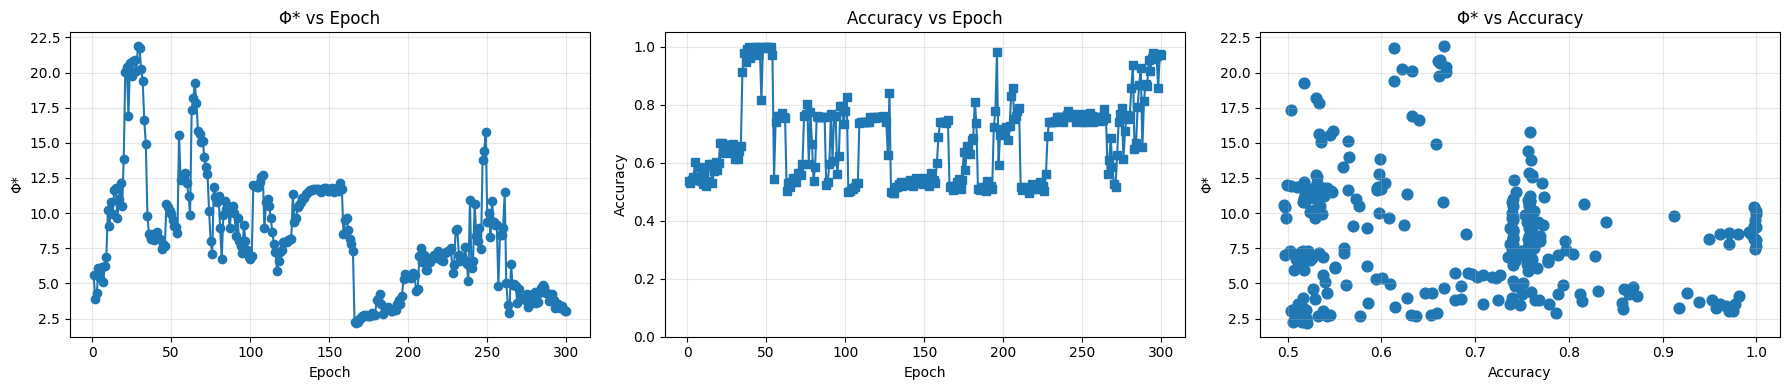

CSV files saved in: /content/phi_results


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass


# CONFIGURATION

device = "cpu"
HIDDEN_SIZE = 60
EPOCHS = 300
BATCH_SIZE = 32
LR = 0.001
MAX_N = 8


# Φ CONFIG

@dataclass
class PhiConfig:
    n_samples: int = 2000
    tau: int = 1
    n_partitions_sample: int = 20

# DATASET

symbol_to_idx = {'X':0,'Y':1,'A':2,'B':3,'EOS':4}

def generate_sequence():
    valid = np.random.rand() > 0.5
    rule = np.random.choice(['X','Y'])
    n = np.random.randint(1, MAX_N+1)

    seq = [rule] + ['A'] * n
    if rule == 'X':
        seq += ['B'] * (n if valid else n+np.random.choice([-1,1]))
    else:
        seq += ['B'] * (2*n if valid else 2*n+np.random.choice([-1,1]))

    seq.append('EOS')
    onehot = np.eye(5)[[symbol_to_idx[s] for s in seq]]
    return onehot, float(valid)

class GrammarDataset(Dataset):
    def __init__(self, n_samples=3000):
        self.data = [generate_sequence() for _ in range(n_samples)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y)

def collate(batch):
    xs, ys = zip(*batch)
    max_len = max(x.shape[0] for x in xs)
    padded = []
    for x in xs:
        pad = torch.zeros(max_len - x.shape[0], 5)
        padded.append(torch.cat([x, pad], 0))
    return torch.stack(padded), torch.tensor(ys)


# RNN MODEL

class GrammarRNN(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=5,
            hidden_size=hidden_size,
            nonlinearity="tanh",
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h = self.rnn(x)
        return torch.sigmoid(self.fc(h.squeeze(0))), h


# HIDDEN STATE COLLECTION

def collect_hidden_states(model, n_samples=2000):
    states = []
    h = None
    with torch.no_grad():
        for _ in range(n_samples):
            x = torch.eye(5)[np.random.randint(0, 5)].view(1, 1, -1)
            _, h = model.rnn(x, h)
            states.append(h.squeeze(0).squeeze(0).cpu().numpy())
    return np.array(states)

# BARRETT & SETH Φ*

class BarrettSethPhiStar:

    def __init__(self, config):
        self.config = config

    def gaussian_mi(self, X, Y):
        n = X.shape[1]
        reg = 1e-6 * np.eye(n)

        Cov_X = np.cov(X.T) + reg
        Cov_Y = np.cov(Y.T) + reg
        Cov_XY = np.cov(np.hstack([X, Y]).T) + 1e-6 * np.eye(2*n)

        sx, logdet_x = np.linalg.slogdet(Cov_X)
        sy, logdet_y = np.linalg.slogdet(Cov_Y)
        sxy, logdet_xy = np.linalg.slogdet(Cov_XY)

        if sx <= 0 or sy <= 0 or sxy <= 0:
            return 0.0

        return 0.5 * (logdet_x + logdet_y - logdet_xy) / np.log(2)

    def estimate(self, states):
        X = states[:-self.config.tau]
        Y = states[self.config.tau:]

        I_whole = self.gaussian_mi(X, Y)
        if I_whole <= 0:
            return 0.0

        n_dim = X.shape[1]
        nodes = np.arange(n_dim)
        min_I_partition = np.inf

        np.random.seed(42)

        for _ in range(self.config.n_partitions_sample):
            k = np.random.randint(1, n_dim // 2 + 1)
            A = np.random.choice(nodes, k, replace=False)
            B = np.setdiff1d(nodes, A)

            if len(B) == 0:
                continue

            I_A = self.gaussian_mi(X[:, A], Y[:, A])
            I_B = self.gaussian_mi(X[:, B], Y[:, B])

            min_I_partition = min(min_I_partition, I_A + I_B)

        return max(I_whole - min_I_partition, 0.0)


# TRAINING LOOP WITH Φ*

def train_with_phi_tracking(config: PhiConfig, phi_samples_per_epoch=500):

    model = GrammarRNN(HIDDEN_SIZE).to(device)
    loader = DataLoader(
        GrammarDataset(),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCELoss()
    phi_estimator = BarrettSethPhiStar(config)

    phi_history = []
    acc_history = []

    for epoch in range(1, EPOCHS + 1):

        # ---- TRAIN ----
        model.train()
        for x, y in loader:
            optimizer.zero_grad()
            pred, _ = model(x)
            loss = criterion(pred.squeeze(), y)
            loss.backward()
            optimizer.step()

        # ---- ACCURACY ----
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in loader:
                pred, _ = model(x)
                pred = (pred.squeeze() > 0.5).float()
                correct += (pred == y).sum().item()
                total += y.size(0)

        acc = correct / total
        acc_history.append(acc)

        # ---- Φ* ----
        states = collect_hidden_states(model, phi_samples_per_epoch)
        phi = phi_estimator.estimate(states)
        phi_history.append(phi)

        print(f"Epoch {epoch:03d} | Acc={acc:.3f} | Φ*={phi:.6f}")

    return phi_history, acc_history


# VISUALIZATION

def plot_results(phi_history, acc_history):

    epochs = np.arange(1, len(phi_history) + 1)
    plt.figure(figsize=(18, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, phi_history, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Φ*")
    plt.title("Φ* vs Epoch")
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, acc_history, marker='s')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.title("Accuracy vs Epoch")
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.scatter(acc_history, phi_history, s=60)
    plt.xlabel("Accuracy")
    plt.ylabel("Φ*")
    plt.title("Φ* vs Accuracy")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# MAIN

if __name__ == "__main__":

    config = PhiConfig(
        n_samples=2000,
        tau=1,
        n_partitions_sample=20
    )

    phi_hist, acc_hist = train_with_phi_tracking(
        config,
        phi_samples_per_epoch=2000
    )

    plot_results(phi_hist, acc_hist)

import os
import pandas as pd
import numpy as np

# -------------------------------
# SAVE DIRECTORY (Colab)
# -------------------------------
SAVE_DIR = "/content/phi_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------
# SAVE CSV FILES
# -------------------------------
def save_results_to_csv(phi_history, acc_history):

    epochs = np.arange(1, len(phi_history) + 1)

    # ---- Φ vs Epoch ----
    df_phi_epoch = pd.DataFrame({
        "epoch": epochs,
        "phi": phi_history
    })
    df_phi_epoch.to_csv(f"{SAVE_DIR}/phi_vs_epoch.csv", index=False)

    # ---- Accuracy vs Epoch ----
    df_acc_epoch = pd.DataFrame({
        "epoch": epochs,
        "accuracy": acc_history
    })
    df_acc_epoch.to_csv(f"{SAVE_DIR}/accuracy_vs_epoch.csv", index=False)

    # ---- Φ vs Accuracy ----
    df_phi_acc = pd.DataFrame({
        "accuracy": acc_history,
        "phi": phi_history
    })
    df_phi_acc.to_csv(f"{SAVE_DIR}/phi_vs_accuracy.csv", index=False)

    # ---- Combined ----
    df_full = pd.DataFrame({
        "epoch": epochs,
        "accuracy": acc_history,
        "phi": phi_history
    })
    df_full.to_csv(f"{SAVE_DIR}/training_summary.csv", index=False)

    print("CSV files saved in:", SAVE_DIR)

save_results_to_csv(phi_hist, acc_hist)


